In [1]:
import os
import anndata as ad
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import omicverse as ov
import scvi
from scvi.model.utils import mde

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.5.3, Tutorials: https://omicverse.readthedocs.io/


[rank: 0] Global seed set to 0


In [2]:
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.set_figure_params(dpi=100)
sc.set_figure_params(figsize=(3, 3))
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (3, 3)

In [3]:
# Change the working directory to the Garfield folder (if needed)
os.chdir('/storage/liuxiaodongLab/fanxueying/mayanalysis/embryomodel_integration')
os.getcwd()

'/storage/liuxiaodongLab/fanxueying/mayanalysis/embryomodel_integration'

In [4]:
# Process query datasets from folder
query_folder = '/storage/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/garfield/in_vitro_embryo_models/processed/data'
# List all h5ad files in the directory
h5ad_files = [os.path.join(query_folder, f) for f in os.listdir(query_folder) if f.startswith('corrected_processed_')]

In [5]:
# Define the output directory
output_dir = '/storage/liuxiaodongLab/fanxueying/mayanalysis/scPoli/scpoli_optim/figures_final_lineage'

# Step 1: List all CSV files in the directory
scpoli_files = [os.path.join(output_dir, f) for f in os.listdir(output_dir) if f.endswith('.csv')]

# Step 2: Initialize an empty dictionary to store the results
scpoli_tables = {}

# Step 3: Process each file
for file in scpoli_files:
    # Read the CSV file into a DataFrame
    scpoli = pd.read_csv(file)
    
    # Extract the desired substring from the file name
    file_name = os.path.basename(file)  # Get the file name without the path
    new_name = file_name.replace('corrected_processed_', '')  # Remove "corrected_processed_"
    new_name = new_name.replace('.h5ad_scPoli_query.csv', '')  # Remove ".h5ad"
    
    # Store the DataFrame in the dictionary with the new name
    scpoli_tables[new_name] = scpoli

# Now `scpoli_tables` is a dictionary where keys are the processed file names and values are the DataFrames

In [6]:
# Read each h5ad file into an AnnData object
adata_list = []
for file in h5ad_files:
    print(f"Reading file: {file}")
    adata = sc.read_h5ad(file)  # Read the h5ad file into AnnData
    adata_list.append(adata)  # Add AnnData object to the list

Reading file: /storage/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/garfield/in_vitro_embryo_models/processed/data/corrected_processed_Oldak.h5ad
Reading file: /storage/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/garfield/in_vitro_embryo_models/processed/data/corrected_processed_Ai_model.h5ad
Reading file: /storage/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/garfield/in_vitro_embryo_models/processed/data/corrected_processed_Hislop.h5ad
Reading file: /storage/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/garfield/in_vitro_embryo_models/processed/data/corrected_processed_zheng_2022.h5ad
Reading file: /storage/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/garfield/in_vitro_embryo_models/processed/data/corrected_processed_Rowan.h5ad
Reading file: /storage/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/garfield/in_vitro_embryo_models/processed/data/corrected_processed_zheng_2019.h5ad
Reading file: /storage/liuxiaodongLab/fanxueying/mayanalysis/2024Aug/garfield/in_vitro_embryo_models/pro

In [7]:
# List of attributes to be extracted from Garfield results
attri = ["final_lineage_pred", "final_lineage_uncert"]

In [8]:
#i=1
#dataset=adata_list[i]

#name = os.path.basename(h5ad_files[i]).replace('.h5ad', '')  # Remove the file extension
#name = name.replace('corrected_processed_', '')  # Remove the file prefix
    
# Get the corresponding scpoli results
#garf = scpoli_tables.get(name)
#garf.index = garf.index.str.replace('-1-1$', '-1', regex=True)


#print(garf)
#print(dataset.obs_names)

In [9]:
# Process each AnnData object and merge with Garfield results
for i, dataset in enumerate(adata_list):
    # Extract the dataset name from the file name
    name = os.path.basename(h5ad_files[i]).replace('.h5ad', '')  
    name = name.replace('corrected_processed_', '')  
    
    # Get the corresponding scpoli results
    garf = scpoli_tables.get(name)
    
    if garf is not None:
        # Check if 'X' is the first column or index
        if garf.columns[0] != 'X':  
            print(f"Warning: The first column is not 'X' for {name}. Renaming the first column.")
            garf.rename(columns={garf.columns[0]: 'X'}, inplace=True)
        
        # Set the first column as index
        garf.set_index('X', inplace=True)
        garf.index = garf.index.str.replace('-1-1$', '-1', regex=True)  # Fix extra "-1"

        # Check if indices match
        if not garf.index.equals(dataset.obs_names):
            print(f"Warning: Indices do not match for {name}. Attempting to fix...")
            
            # Standardize index formatting
            garf.index = garf.index.astype(str)  # Ensure string format
            dataset.obs_names = dataset.obs_names.astype(str)
            
            # Try stripping potential "-1" suffix
            garf.index = garf.index.str.replace('-1$', '', regex=True)
            dataset.obs_names = dataset.obs_names.str.replace('-1$', '', regex=True)
            
            # Check again after fixing
            if not garf.index.equals(dataset.obs_names):
                print(f"Error: Indices still do not match for {name}. Skipping this dataset.")
                continue

        # Extract required columns
        garf = garf[attri]
        
        # Remove filtered cells
        dataset = dataset[dataset.obs_names.isin(garf.index), :]
        
        # Ensure row names match
        garf = garf.loc[dataset.obs_names, :]
        
        # Add prefix to column names
        garf.columns = [f"human_ref_{col}" for col in garf.columns]

        # Merge into AnnData metadata
        dataset.obs = pd.concat([dataset.obs, garf], axis=1)

        # Update dataset in the list
        adata_list[i] = dataset
    else:
        print(f"No scpoli data found for {name}")


In [10]:
# Merge all AnnData objects into one
# We use `anndata.concat()` to merge them, making sure the 'obs' and 'var' fields align
combined_adata = ad.concat(adata_list, label='batch', join='outer')

# Print the shape of the merged AnnData to verify
print(f"Combined AnnData shape: {combined_adata.shape}")


Combined AnnData shape: (142232, 35142)


In [11]:
combined_adata

AnnData object with n_obs × n_vars = 142232 × 35142
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'human_ref_final_lineage_pred', 'human_ref_final_lineage_uncert', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'batch'

In [12]:
set(combined_adata.obs["orig.ident"])

{'Ai_model',
 'Hislop',
 'Liu',
 'Oldak',
 'Pedroza',
 'Rowan',
 'Weatherbee',
 'Zheng_2019',
 'zheng_2022'}

In [13]:
print(combined_adata.X)

  (0, 11375)	1.0
  (0, 24981)	46.0
  (0, 24987)	5.0
  (0, 24985)	26.0
  (0, 24984)	19.0
  (0, 24980)	55.0
  (0, 24976)	60.0
  (0, 24977)	1.0
  (0, 24979)	75.0
  (0, 24978)	57.0
  (0, 24983)	5.0
  (0, 24982)	11.0
  (0, 33698)	1.0
  (0, 21303)	1.0
  (0, 29198)	29.0
  (0, 25253)	1.0
  (0, 13343)	2.0
  (0, 14635)	1.0
  (0, 33766)	1.0
  (0, 19733)	2.0
  (0, 8352)	2.0
  (0, 28722)	1.0
  (0, 29391)	1.0
  (0, 24757)	1.0
  (0, 28587)	3.0
  :	:
  (142231, 16313)	1.0
  (142231, 24518)	2.0
  (142231, 14279)	1.0
  (142231, 25505)	2.0
  (142231, 31579)	1.0
  (142231, 11029)	1.0
  (142231, 32470)	1.0
  (142231, 20701)	1.0
  (142231, 33785)	2.0
  (142231, 14975)	1.0
  (142231, 27111)	1.0
  (142231, 25736)	1.0
  (142231, 23960)	1.0
  (142231, 30264)	1.0
  (142231, 24586)	1.0
  (142231, 17281)	4.0
  (142231, 28813)	2.0
  (142231, 26724)	3.0
  (142231, 14243)	1.0
  (142231, 29212)	4.0
  (142231, 18910)	4.0
  (142231, 24693)	1.0
  (142231, 31227)	1.0
  (142231, 24848)	2.0
  (142231, 13208)	2.0


In [14]:
combined_adata.layers["counts"] = combined_adata.X.copy()

In [15]:
sc.settings.seed = 42
sc.pp.normalize_total(combined_adata, target_sum=1e4)
sc.pp.log1p(combined_adata)
combined_adata.layers["logcounts"] = combined_adata.X.copy()
sc.pp.highly_variable_genes(combined_adata, n_top_genes=2000, flavor="cell_ranger", batch_key="orig.ident")
sc.tl.pca(combined_adata, n_comps=30, use_highly_variable=True)

In [16]:
adata_hvg = combined_adata[:, combined_adata.var.highly_variable].copy()

In [17]:
adata_hvg

AnnData object with n_obs × n_vars = 142232 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'human_ref_final_lineage_pred', 'human_ref_final_lineage_uncert', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'batch'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts', 'logcounts'

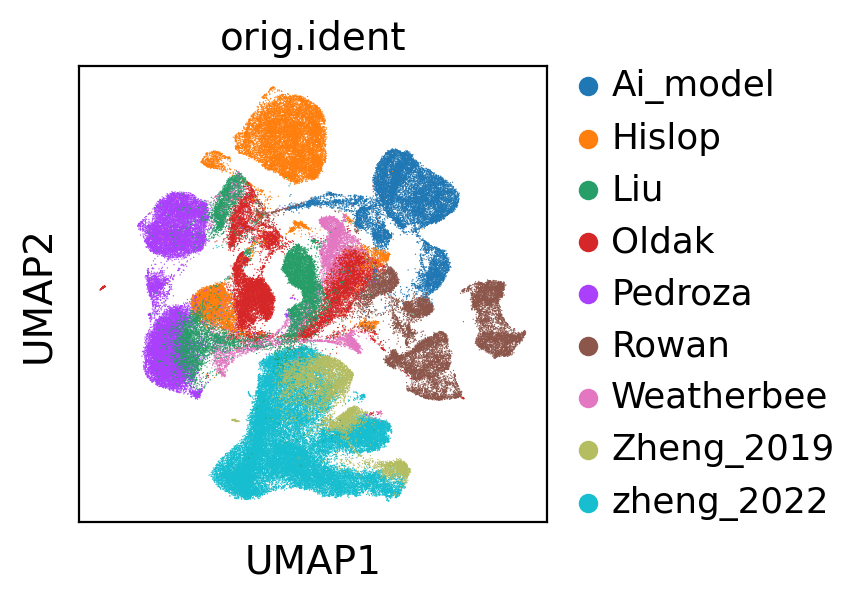

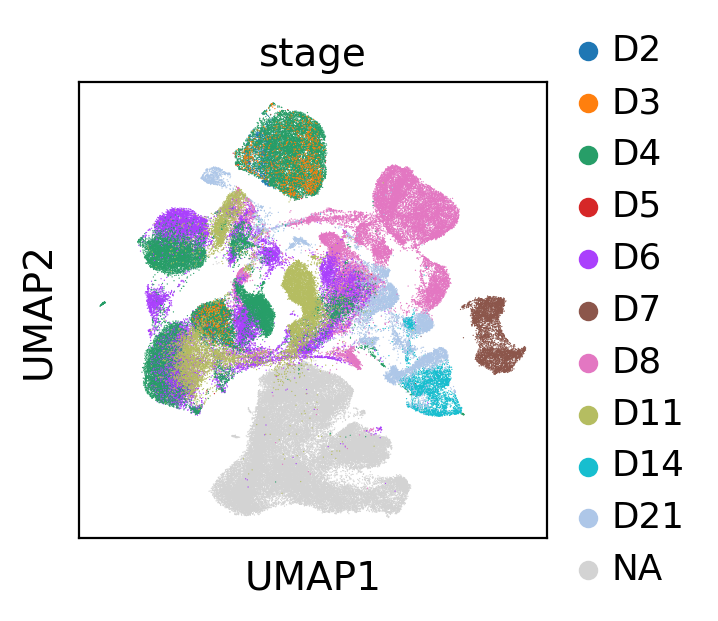

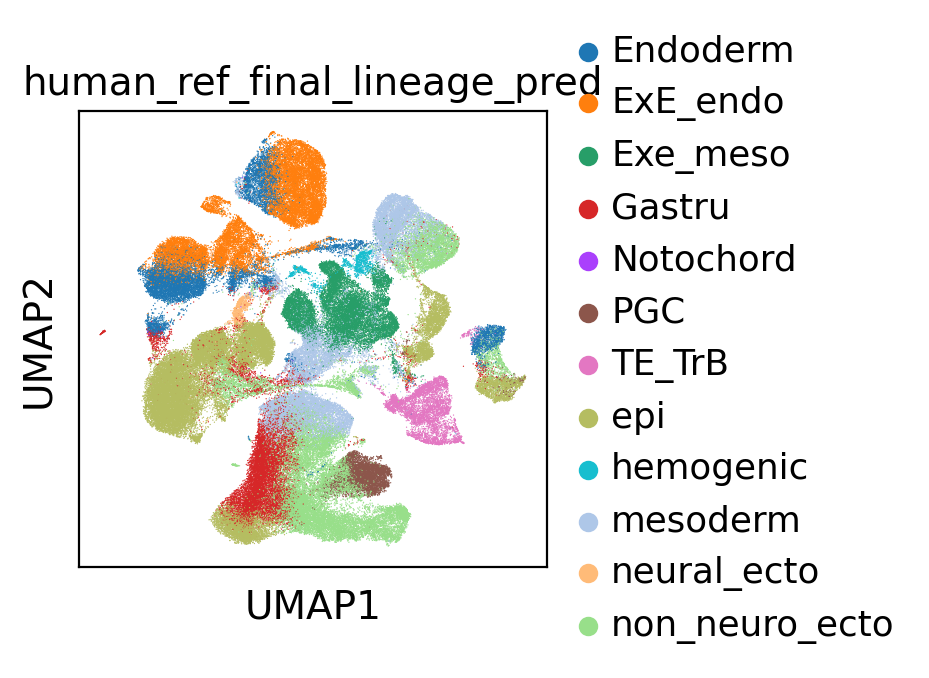

In [18]:
####Unintegrated
combined_adata.obsm["Unintegrated"] = adata_hvg.obsm["X_pca"]
adata_hvg.obsm["Unintegrated"] = adata_hvg.obsm["X_pca"]
sc.pp.neighbors(combined_adata, use_rep="Unintegrated",random_state=42)
sc.tl.leiden(combined_adata, resolution=0.5,key_added=f"Unintegrated_res_0.5",random_state=42)
sc.tl.umap(combined_adata,random_state=42)
combined_adata.obsm['X_Unintegrated'] = combined_adata.obsm['X_umap']
sc.pl.umap(combined_adata, color=['orig.ident'], save="Unintegrated_orig_ident.pdf")
sc.pl.umap(combined_adata, color=['stage'], save="Unintegrated_stage.pdf")
sc.pl.umap(combined_adata, color=['human_ref_final_lineage_pred'], save="human_ref_final_lineage_pred.pdf")

In [19]:
###scVI
scvi.model.SCVI.setup_anndata(adata_hvg, layer="counts", batch_key="orig.ident")
vae = scvi.model.SCVI(adata_hvg, gene_likelihood="nb", n_layers=2, n_latent=30)
vae.train()

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 56/56: 100%|██████████| 56/56 [20:10<00:00, 22.22s/it, loss=1.03e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=56` reached.


Epoch 56/56: 100%|██████████| 56/56 [20:10<00:00, 21.62s/it, loss=1.03e+03, v_num=1]


In [20]:
combined_adata.obsm["scVI"] = vae.get_latent_representation()

In [21]:
###scANVI
lvae = scvi.model.SCANVI.from_scvi_model(
    vae,
    adata=adata_hvg,
    labels_key="human_ref_final_lineage_pred",
    unlabeled_category="Unknown",
)
lvae.train(max_epochs=20, n_samples_per_label=100)

INFO     Training for 20 epochs.                                                                                   


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Epoch 20/20: 100%|██████████| 20/20 [12:46<00:00, 38.45s/it, loss=1.13e+03, v_num=1]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|██████████| 20/20 [12:46<00:00, 38.34s/it, loss=1.13e+03, v_num=1]


In [22]:
combined_adata.obsm["scANVI"] = lvae.get_latent_representation()

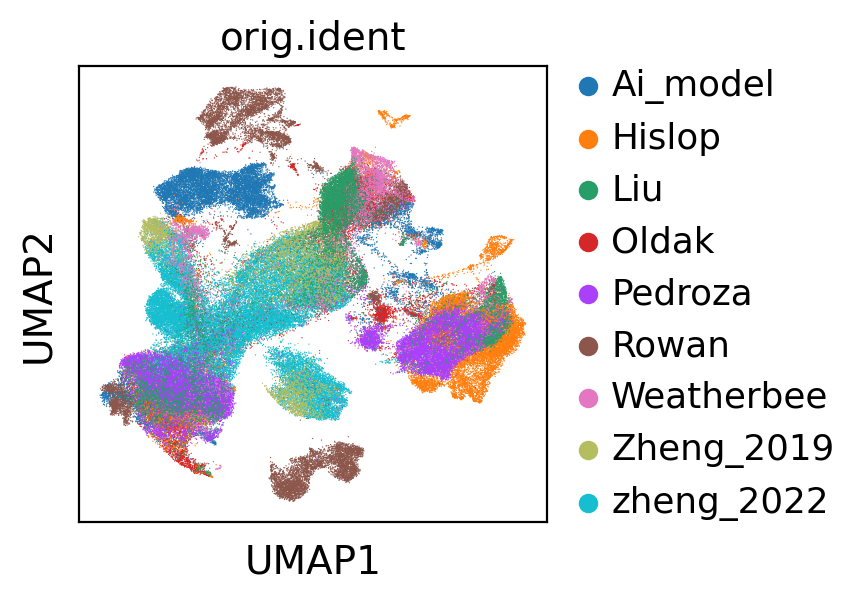

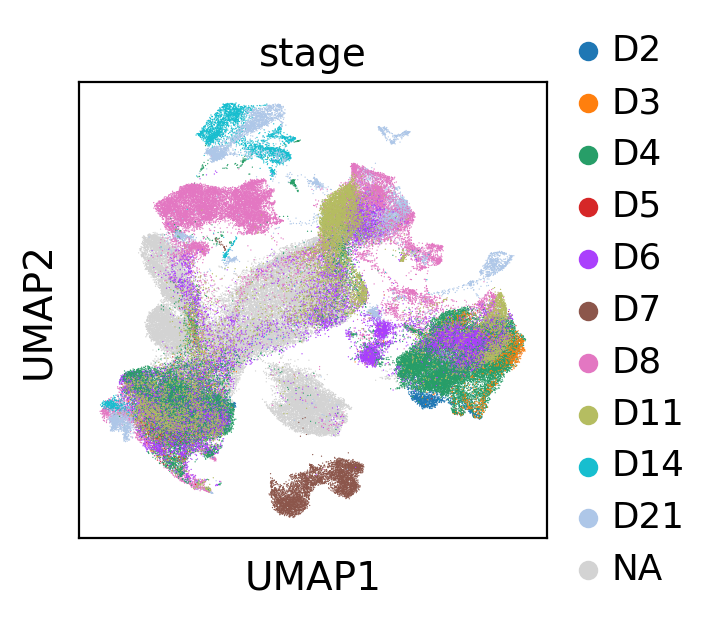

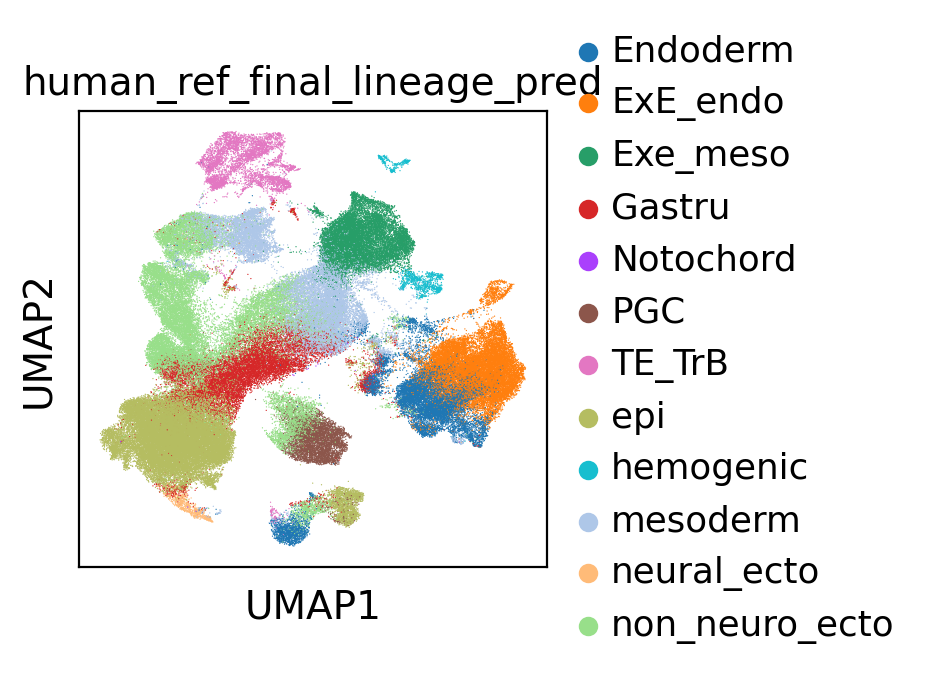

In [23]:
adata_hvg.obsm["scANVI"] = combined_adata.obsm["scANVI"]
sc.pp.neighbors(combined_adata, use_rep="scANVI",random_state=42)
sc.tl.leiden(combined_adata, resolution=0.5,key_added=f"scANVI_res_0.5",random_state=42)
sc.tl.umap(combined_adata,random_state=42)
combined_adata.obsm['X_scANVI'] = combined_adata.obsm['X_umap']
adata_hvg.obsm['X_scANVI'] = combined_adata.obsm['X_scANVI']
sc.pl.umap(combined_adata, color=['orig.ident'],save="scANVI_orig.ident.pdf")
sc.pl.umap(combined_adata, color=['stage'],save="scANVI_stage.pdf")
sc.pl.umap(combined_adata, color=['human_ref_final_lineage_pred'],save="scpoli_transferred_final_lineage.pdf")

In [24]:
# Check current working directory
print("Current working directory:", os.getcwd())

Current working directory: /storage/liuxiaodongLab/fanxueying/mayanalysis/embryomodel_integration


In [26]:
combined_adata.raw.var.rename(columns={'_index': 'index'}, inplace=True)
combined_adata.write_h5ad(filename="embryo_model_integration_scPoli_20250311.h5ad")

In [ ]:
# add scpoli final_anno pred to the data

In [27]:
# Define the output directory
output_dir = '/storage/liuxiaodongLab/fanxueying/mayanalysis/scPoli/scpoli_optim/figures_final_anno'

# Step 1: List all CSV files in the directory
scpoli_files = [os.path.join(output_dir, f) for f in os.listdir(output_dir) if f.endswith('.csv')]

# Step 2: Initialize an empty dictionary to store the results
scpoli_tables = {}

# Step 3: Process each file
for file in scpoli_files:
    # Read the CSV file into a DataFrame
    scpoli = pd.read_csv(file)
    
    # Extract the desired substring from the file name
    file_name = os.path.basename(file)  # Get the file name without the path
    new_name = file_name.replace('corrected_processed_', '')  # Remove "corrected_processed_"
    new_name = new_name.replace('.h5ad_scPoli_query.csv', '')  # Remove ".h5ad"
    
    # Store the DataFrame in the dictionary with the new name
    scpoli_tables[new_name] = scpoli

# Now `scpoli_tables` is a dictionary where keys are the processed file names and values are the DataFrames

In [28]:
# List of attributes to be extracted from Garfield results
attri = ["final_anno_pred", "final_anno_uncert"]

In [29]:
# Process each AnnData object and merge with Garfield results
for i, dataset in enumerate(adata_list):
    # Extract the dataset name from the file name
    name = os.path.basename(h5ad_files[i]).replace('.h5ad', '')  
    name = name.replace('corrected_processed_', '')  
    
    # Get the corresponding scpoli results
    garf = scpoli_tables.get(name)
    
    if garf is not None:
        # Check if 'X' is the first column or index
        if garf.columns[0] != 'X':  
            print(f"Warning: The first column is not 'X' for {name}. Renaming the first column.")
            garf.rename(columns={garf.columns[0]: 'X'}, inplace=True)
        
        # Set the first column as index
        garf.set_index('X', inplace=True)
        garf.index = garf.index.str.replace('-1-1$', '-1', regex=True)  # Fix extra "-1"

        # Check if indices match
        if not garf.index.equals(dataset.obs_names):
            print(f"Warning: Indices do not match for {name}. Attempting to fix...")
            
            # Standardize index formatting
            garf.index = garf.index.astype(str)  # Ensure string format
            dataset.obs_names = dataset.obs_names.astype(str)
            
            # Try stripping potential "-1" suffix
            garf.index = garf.index.str.replace('-1$', '', regex=True)
            dataset.obs_names = dataset.obs_names.str.replace('-1$', '', regex=True)
            
            # Check again after fixing
            if not garf.index.equals(dataset.obs_names):
                print(f"Error: Indices still do not match for {name}. Skipping this dataset.")
                continue

        # Extract required columns
        garf = garf[attri]
        
        # Remove filtered cells
        dataset = dataset[dataset.obs_names.isin(garf.index), :]
        
        # Ensure row names match
        garf = garf.loc[dataset.obs_names, :]
        
        # Add prefix to column names
        garf.columns = [f"human_ref_{col}" for col in garf.columns]

        # Merge into AnnData metadata
        dataset.obs = pd.concat([dataset.obs, garf], axis=1)

        # Update dataset in the list
        adata_list[i] = dataset
    else:
        print(f"No scpoli data found for {name}")


In [30]:
# Merge all AnnData objects into one
# We use `anndata.concat()` to merge them, making sure the 'obs' and 'var' fields align
combined_adata = ad.concat(adata_list, label='batch', join='outer')

# Print the shape of the merged AnnData to verify
print(f"Combined AnnData shape: {combined_adata.shape}")

Combined AnnData shape: (142232, 35142)


In [31]:
combined_adata

AnnData object with n_obs × n_vars = 142232 × 35142
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'human_ref_final_lineage_pred', 'human_ref_final_lineage_uncert', 'human_ref_final_anno_pred', 'human_ref_final_anno_uncert', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'batch'

In [32]:
adata = sc.read_h5ad("embryo_model_integration_scPoli_20250311.h5ad")  

In [33]:
adata

AnnData object with n_obs × n_vars = 142232 × 35142
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'doublet', 'doublet_score', 'human_ref_final_lineage_pred', 'human_ref_final_lineage_uncert', 'sample_type', 'scmap_nakamura', 'scmapCELL_Yang', 'scmap_ma', 'scmap_Tyser', 'scmapCELL_Mole', 'cell_assignment', 'course_cell_assignment', 'batch', 'Unintegrated_res_0.5', 'scANVI_res_0.5'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'human_ref_final_lineage_pred_colors', 'hvg', 'leiden', 'log1p', 'neighbors', 'orig.ident_colors', 'pca', 'stage_colors', 'umap'
    obsm: 'Unintegrated', 'X_Unintegrated', 'X_pca', 'X_scANVI', 'X_umap', 'scANVI', 'scVI'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [34]:
# Ensure indices match between the two AnnData objects
matching_indices = combined_adata.obs.index.intersection(adata.obs.index)

# Select relevant columns and subset based on matching indices
adata.obs.loc[matching_indices, ["human_ref_final_anno_pred", "human_ref_final_anno_uncert"]] = \
    combined_adata.obs.loc[matching_indices, ["human_ref_final_anno_pred", "human_ref_final_anno_uncert"]]

In [35]:
# Check for NA values in the added columns
na_check = adata.obs[["human_ref_final_anno_pred", "human_ref_final_anno_uncert"]].isna().sum()

# Print the count of NA values
print("Number of NAs in each column after update:")
print(na_check)

Number of NAs in each column after update:
human_ref_final_anno_pred      0
human_ref_final_anno_uncert    0
dtype: int64


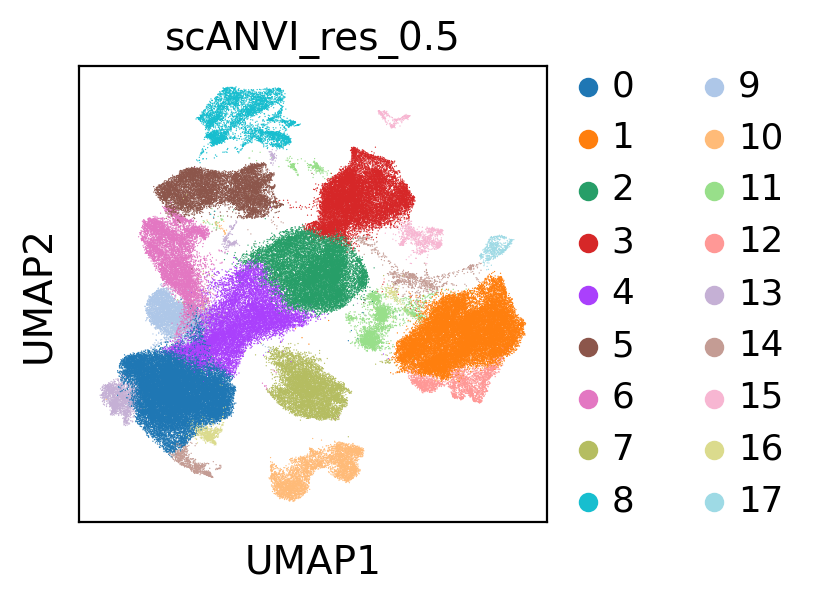

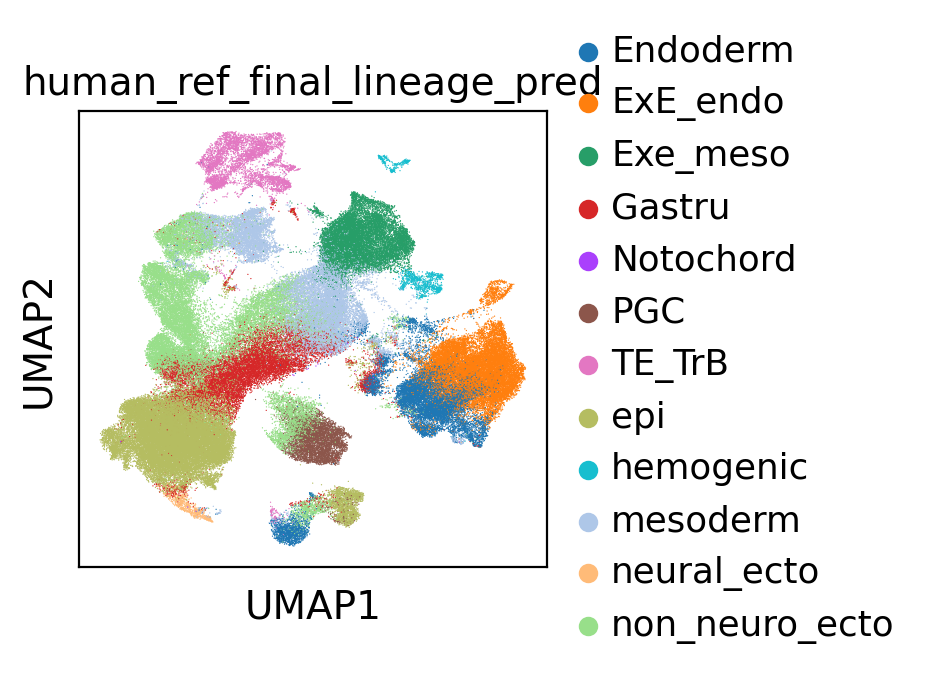

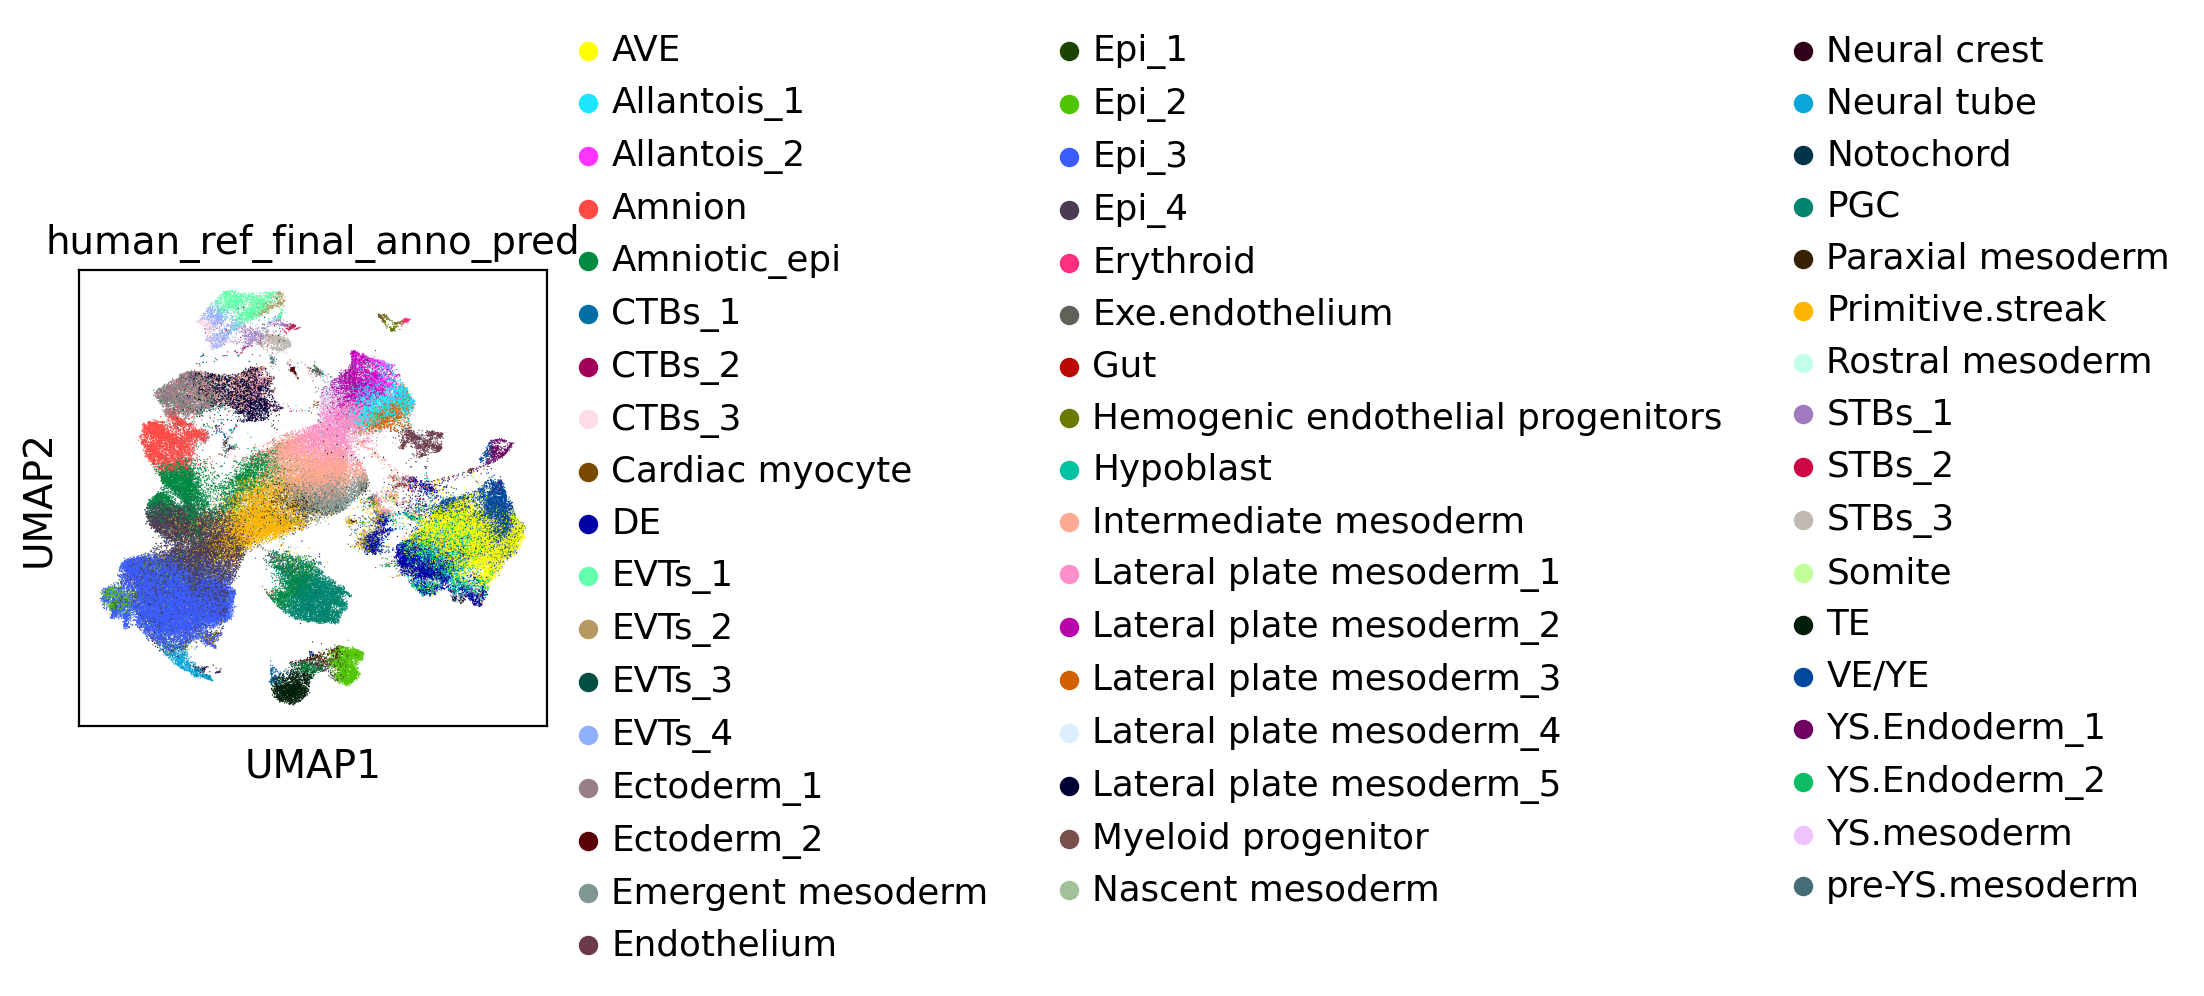

In [36]:
adata.obsm['X_umap']=adata.obsm['X_scANVI']
sc.pl.umap(adata, color=['scANVI_res_0.5'])
sc.pl.umap(adata, color=['human_ref_final_lineage_pred'])
sc.pl.umap(adata, color=['human_ref_final_anno_pred'])

In [43]:
# Define the ordered labels
lineage_ordered_labels = [
    "Endoderm", "epi", "ExE_endo", "Exe_meso", "hemogenic",
    "mesoderm", "neural_ecto", "non_neuro_ecto", "Notochord",
    "PGC", "TE_TrB", "Gastru"
]

In [44]:
# Ensure the column is treated as categorical with the specified order
adata.obs["human_ref_final_lineage_pred"] = pd.Categorical(
    adata.obs["human_ref_final_lineage_pred"],
    categories=lineage_ordered_labels,
    ordered=True
)

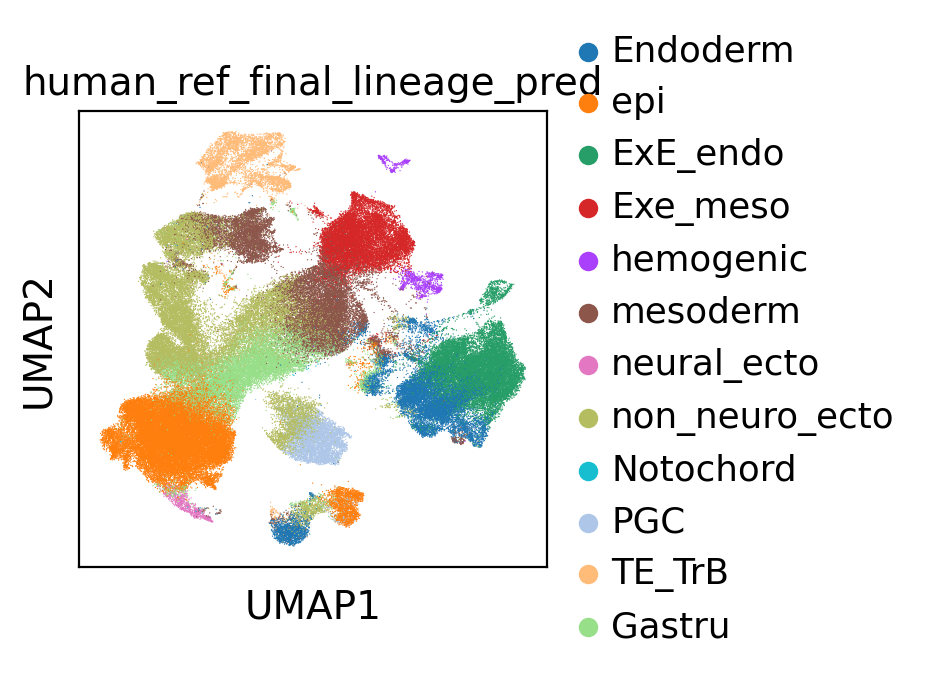

In [45]:
sc.pl.umap(adata, color=['human_ref_final_lineage_pred'],  save="scpoli_enhanced_lineage.pdf")

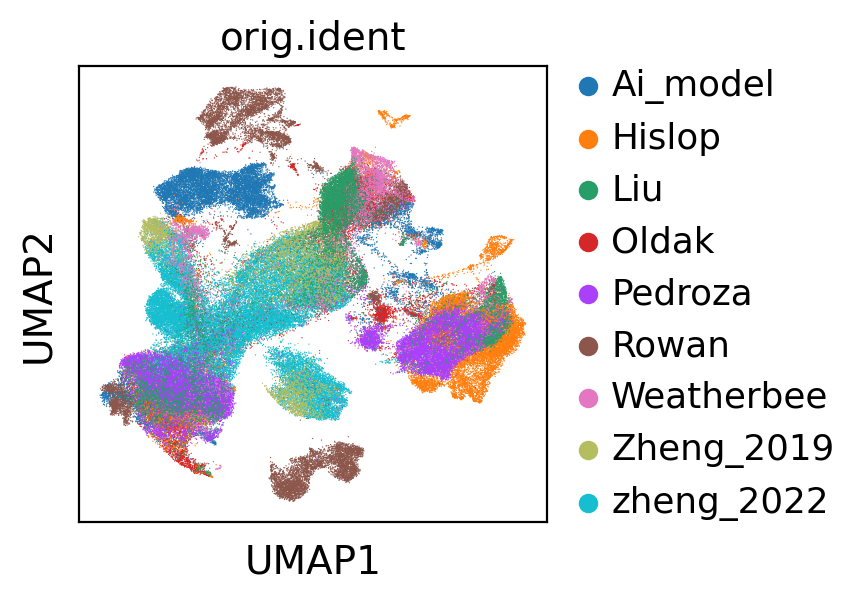

In [46]:
sc.pl.umap(adata, color=['orig.ident'],  save="scpoli_enhanced_dataset.pdf")

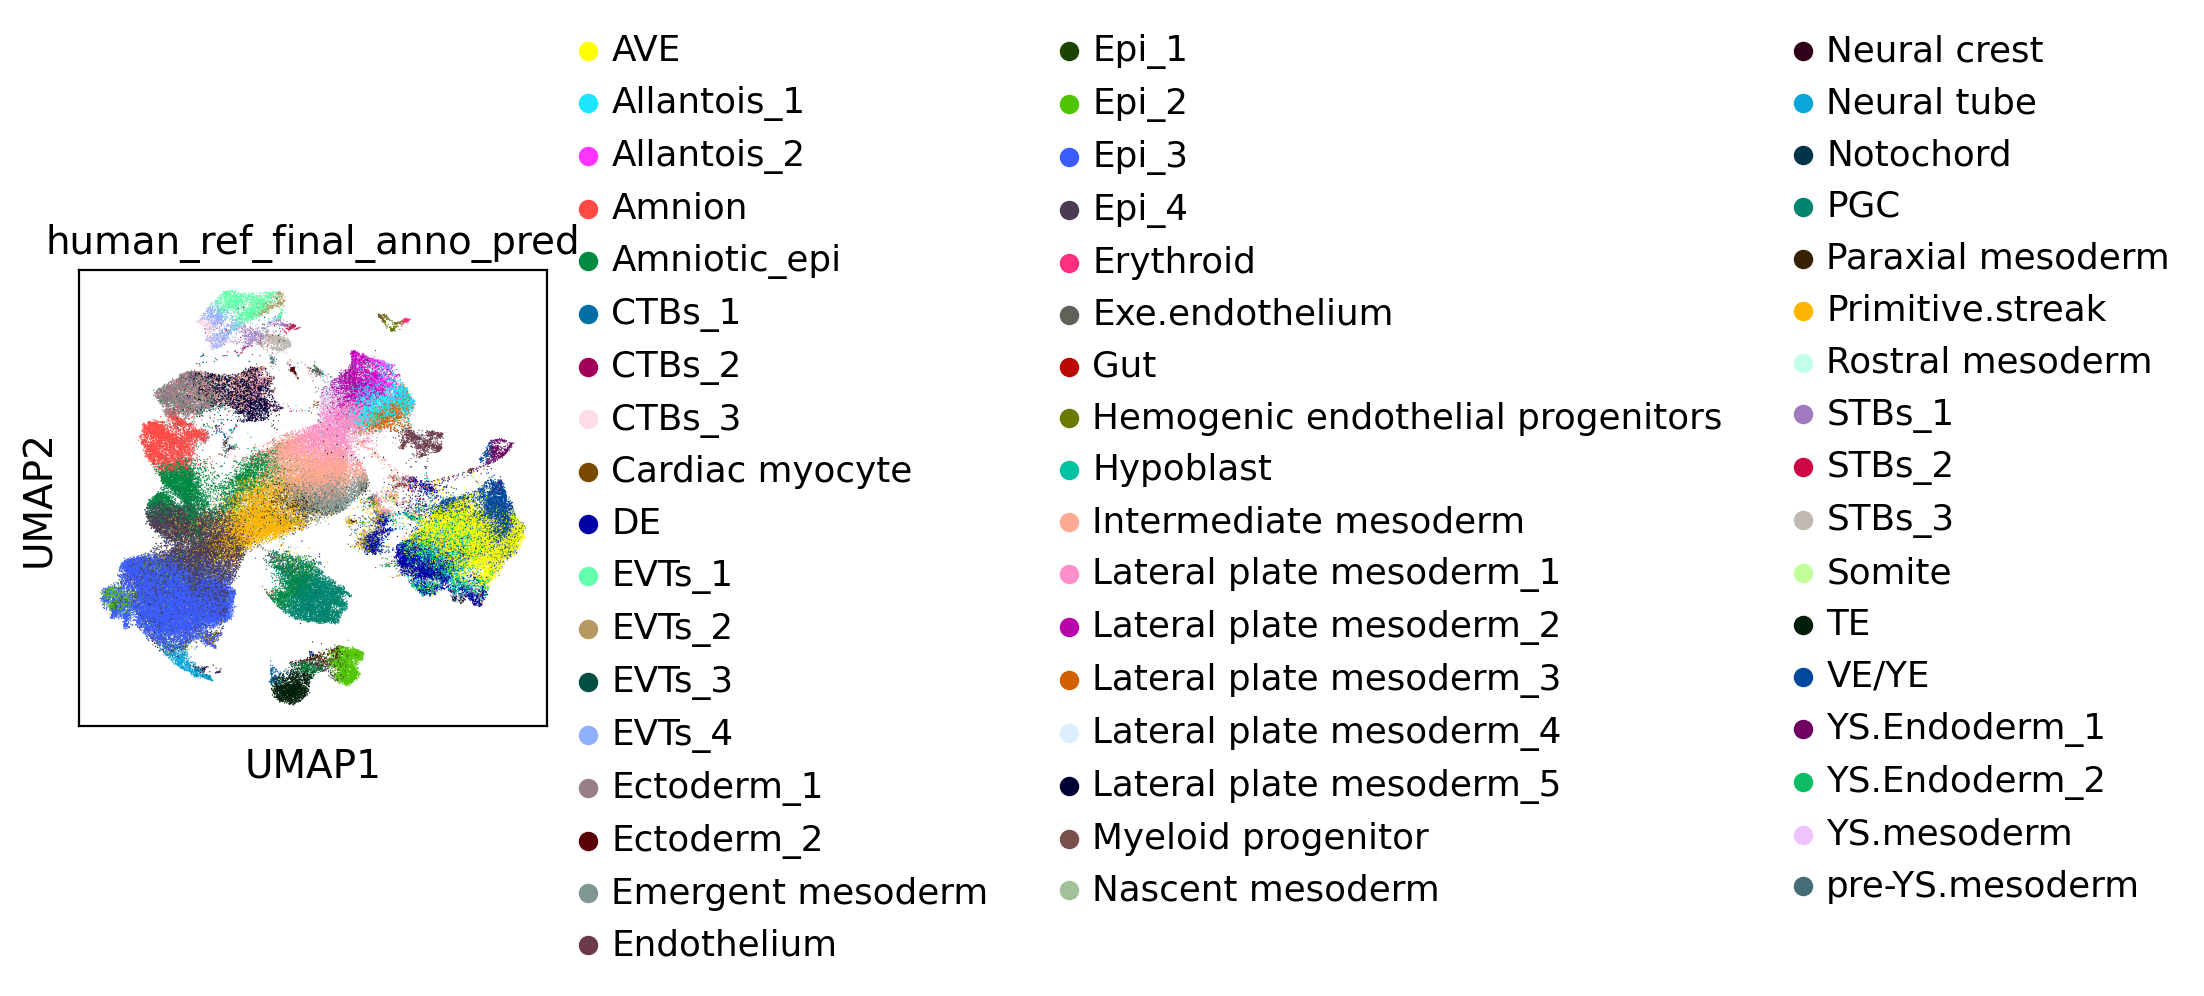

In [38]:
sc.pl.umap(adata, color=['human_ref_final_anno_pred'],  save="scpoli_enhanced_anno.pdf")

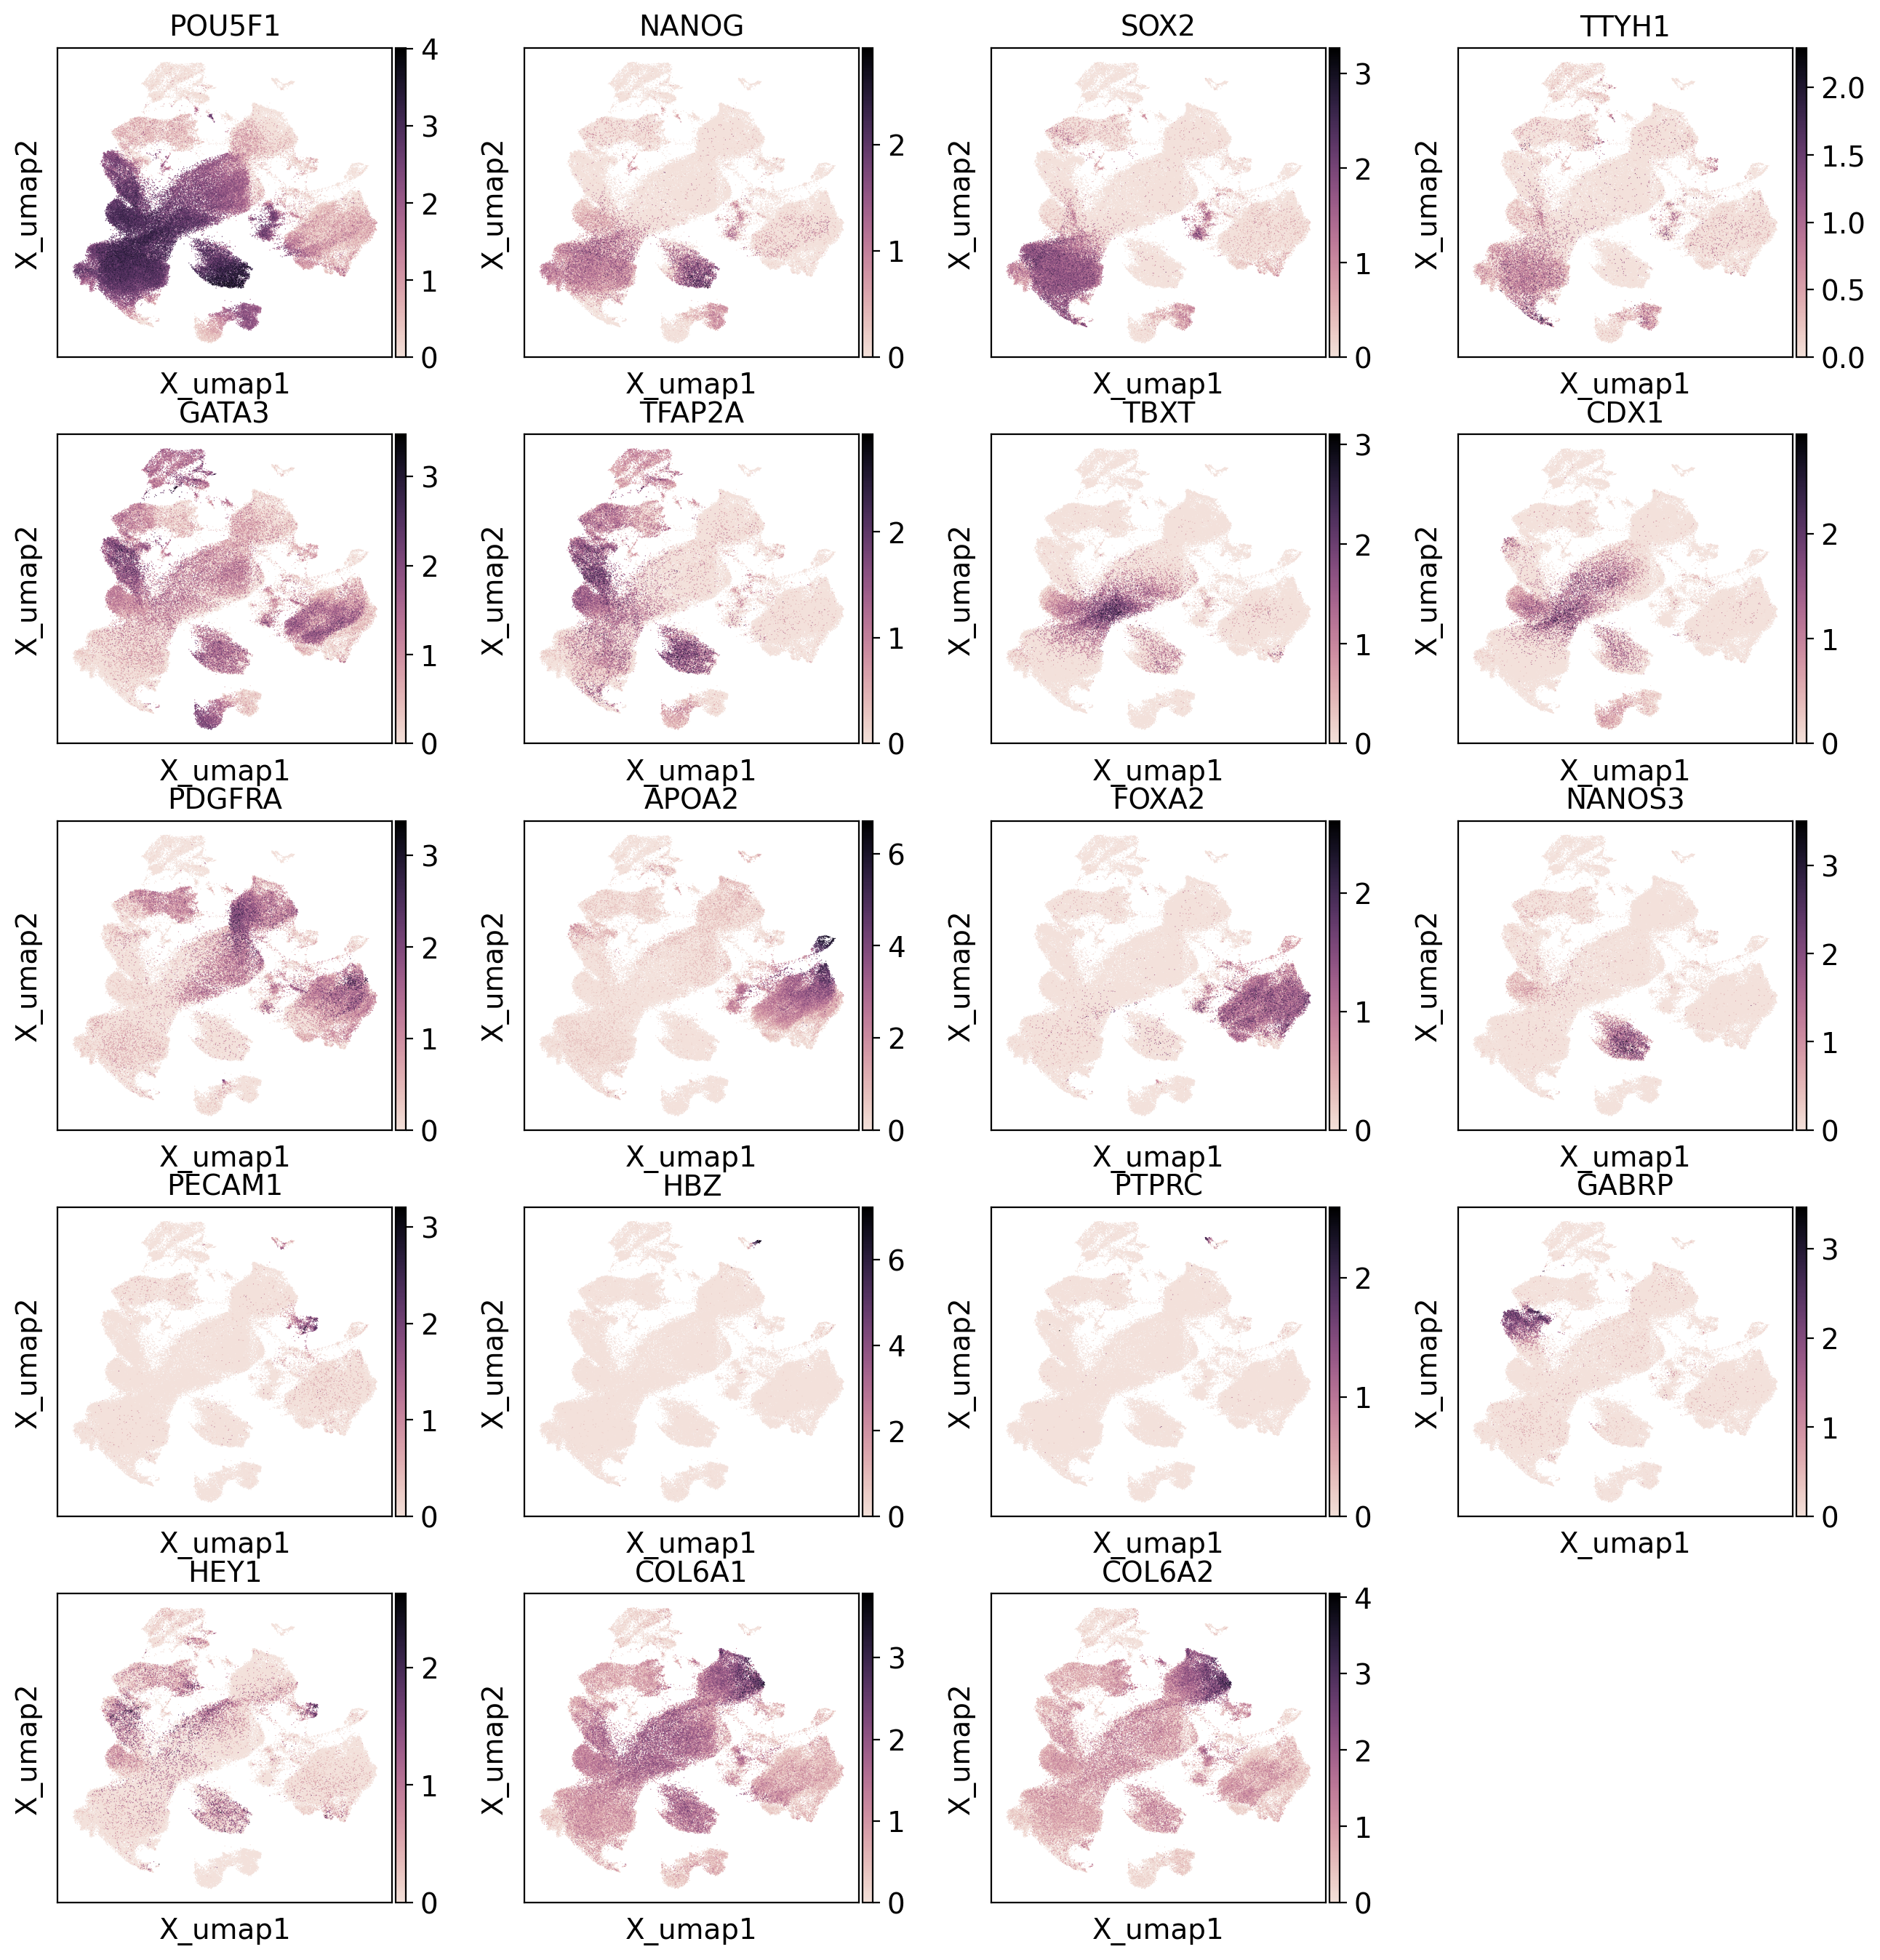

In [41]:
# Define the list of genes you want to plot
genes_to_plot = ["POU5F1","NANOG",#epiblast
                 "SOX2", "TTYH1", #Neural_ectoderm
                 "GATA3","TFAP2A",
                 "TBXT",  "CDX1","PDGFRA","APOA2","FOXA2","NANOS3",
                "PECAM1","HBZ","PTPRC",
                "GABRP","HEY1","COL6A1","COL6A2",]  # Replace "GENE2" and "GENE3" with the actual gene names

# Plot the UMAP embedding for the specified genes
sc.pl.embedding(
    adata,
    basis='X_umap',
    color=genes_to_plot,
    use_raw=False,
    cmap=sns.cubehelix_palette(dark=0, light=.9, as_cmap=True),
    save="scpoli_enhanced_gene_umaps.pdf"  # Saves all plots in a single PDF
)

In [42]:
# save again
adata.raw.var.rename(columns={'_index': 'index'}, inplace=True)
adata.write_h5ad(filename="embryo_model_integration_scPoli_20250311.h5ad")